# Machine Learning Assignment - Week 3
## Simple Linear Regression with Gradient Descent

**Objective:**
We will implement Simple Linear Regression in two ways:
1. **Part A:** Using scikit-learn's `LinearRegression`.
2. **Part B:** Implementing Gradient Descent from scratch.

Finally, we will compare the slope and intercept learned by both methods.

**Dataset:** Vehicle Insurance Fraud (`insurance_fraud_data.csv`)

### Selected Columns & Suitability
- **Feature (X):** `age_of_driver` (Driver's age)
- **Target (Y):** `annual_income` (Driver's annual income)

**Why is the target column suitable for Linear Regression?**
- **Continuous Numeric:** `annual_income` is a continuous numerical column, which is required for regression models.
- **Logical Relationship:** Older drivers typically have more work experience, which leads to higher annual income. Linear regression helps us capture this relationship.
- **Linear Trend:** We can easily fit a straight line ($Y = mX + c$) to predict income based on the driver's age.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('insurance_fraud_data.csv')

# Display dataset size and the first 5 rows of our selected columns
print("Dataset Shape:", df.shape)
print(df[['age_of_driver', 'annual_income']].head())

Dataset Shape: (12002, 29)
   age_of_driver  annual_income
0             39        58612.8
1             33        35936.0
2             31        84940.8
3             53        73526.4
4             41        59403.2


### Step 2: Scale and Split the Dataset
- To help Gradient Descent converge quickly and easily without using advanced libraries, we scale the columns by dividing them by simple constants (driver's age by 100, and income by 100,000).
- We then split the data into 80% training and 20% testing sets.

In [3]:
# Simple scaling to keep values between 0 and 2 (helps Gradient Descent run smoothly)
X = df['age_of_driver'].values / 100.0
y = df['annual_income'].values / 100000.0

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 9601
Testing samples: 2401


## Part A: Using Scikit-learn
We train the standard scikit-learn `LinearRegression` model. Since scikit-learn expects a 2D array for the input features, we reshape our 1D arrays using `.reshape(-1, 1)`.

In [4]:
# Reshape 1D arrays to 2D for scikit-learn
X_train_2d = X_train.reshape(-1, 1)
X_test_2d = X_test.reshape(-1, 1)

# Train the model
model = LinearRegression()
model.fit(X_train_2d, y_train)

# Get learned coefficients
sklearn_slope = model.coef_[0]
sklearn_intercept = model.intercept_

print("--- Scikit-learn Coefficients ---")
print("Slope (m):", sklearn_slope)
print("Intercept (c):", sklearn_intercept)

# Make predictions and calculate performance metrics
y_pred_sklearn = model.predict(X_test_2d)
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
r2_sklearn = r2_score(y_test, y_pred_sklearn)

print("\n--- Model Performance ---")
print("Mean Squared Error (MSE):", mse_sklearn)
print("R2 Score:", r2_sklearn)

--- Scikit-learn Coefficients ---
Slope (m): 0.3024898697270953
Intercept (c): 0.5053030702285972

--- Model Performance ---
Mean Squared Error (MSE): 0.031643948783668725
R2 Score: 0.051839019745445025


## Part B: Gradient Descent From Scratch
Here, we implement the optimization loop without any ML libraries. We start with slope (`m`) and intercept (`c`) as `0.0`, and iteratively update them using calculated gradients.

### Formulas Used:
- **Predictions:** $\text{y\_pred} = m \cdot X + c$
- **Error:** $\text{error} = \text{y\_pred} - y$
- **Loss (MSE):** $\text{loss} = \frac{1}{n} \sum \text{error}^2$
- **Slope Gradient:** $dm = \frac{2}{n} \sum (\text{error} \cdot X)$
- **Intercept Gradient:** $dc = \frac{2}{n} \sum \text{error}$
- **Parameter Update:** $m = m - \text{learning\_rate} \cdot dm$, $c = c - \text{learning\_rate} \cdot dc$

In [5]:
# Initialize weights and bias
m = 0.0
c = 0.0

# Define hyperparameters
learning_rate = 0.1
epochs = 5000
n = len(X_train)

# Store loss values for plotting
loss_history = []

print("Starting Gradient Descent loop...")
for epoch in range(epochs):
    # 1. Predict values using current m and c
    y_pred_manual = m * X_train + c
    
    # 2. Calculate the difference (predicted - actual)
    error = y_pred_manual - y_train
    
    # 3. Calculate MSE loss and store it
    loss = (1 / n) * np.sum(error ** 2)
    loss_history.append(loss)
    
    # 4. Calculate gradients manually
    dm = (2 / n) * np.sum(error * X_train)
    dc = (2 / n) * np.sum(error)
    
    # 5. Update weights and bias manually
    m = m - learning_rate * dm
    c = c - learning_rate * dc
    
    # Print training status every 500 epochs
    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d}: Loss = {loss:.6f} | m = {m:.4f} | c = {c:.4f}")

print("\nTraining complete!")
print("Final learned slope (m):", m)
print("Final learned intercept (c):", c)

Starting Gradient Descent loop...
Epoch    0: Loss = 0.435082 | m = 0.0565 | c = 0.1274
Epoch  500: Loss = 0.027662 | m = 0.2835 | c = 0.5137
Epoch 1000: Loss = 0.027657 | m = 0.2970 | c = 0.5077
Epoch 1500: Loss = 0.027656 | m = 0.3009 | c = 0.5060
Epoch 2000: Loss = 0.027656 | m = 0.3020 | c = 0.5055
Epoch 2500: Loss = 0.027656 | m = 0.3024 | c = 0.5054
Epoch 3000: Loss = 0.027656 | m = 0.3025 | c = 0.5053
Epoch 3500: Loss = 0.027656 | m = 0.3025 | c = 0.5053
Epoch 4000: Loss = 0.027656 | m = 0.3025 | c = 0.5053
Epoch 4500: Loss = 0.027656 | m = 0.3025 | c = 0.5053

Training complete!
Final learned slope (m): 0.3024896204054519
Final learned intercept (c): 0.5053031803420843


### Plotting Loss vs Epochs
We plot the Mean Squared Error (Loss) against the number of epochs to verify that our model converged successfully.

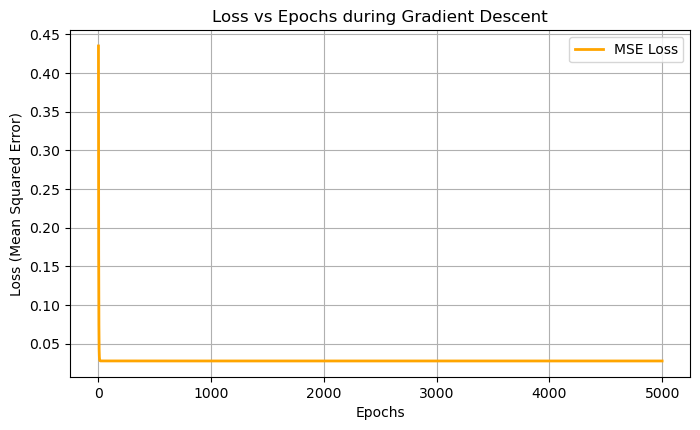

In [6]:
# Plot the loss curve
plt.figure(figsize=(8, 4.5))
plt.plot(loss_history, color='orange', linewidth=2, label='MSE Loss')
plt.title('Loss vs Epochs during Gradient Descent')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

## Comparing Coefficients
Let's compare the parameters obtained from scikit-learn and our manual Gradient Descent.

In [7]:
print("--- Side-by-Side Comparison ---")
print(f"Scikit-learn Slope (m):      {sklearn_slope:.6f}")
print(f"Gradient Descent Slope (m):  {m:.6f}")
print(f"Slope Difference:            {abs(sklearn_slope - m):.6f}")
print()
print(f"Scikit-learn Intercept (c):  {sklearn_intercept:.6f}")
print(f"Gradient Descent Intercept(c): {c:.6f}")
print(f"Intercept Difference:        {abs(sklearn_intercept - c):.6f}")

--- Side-by-Side Comparison ---
Scikit-learn Slope (m):      0.302490
Gradient Descent Slope (m):  0.302490
Slope Difference:            0.000000

Scikit-learn Intercept (c):  0.505303
Gradient Descent Intercept(c): 0.505303
Intercept Difference:        0.000000
